# Making Predictions Using Data

In this notebook, we will explore how to use data to make predictions.


## Setup: Importing Libraries

Before we begin, install the scipy libary.

`conda install conda-forge::scipy`

or

`python -m pip install scipy`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

%matplotlib inline

## 1. What is Regression?

**Regression** is the process of finding a mathematical relationship between variables so that we can:
- Understand the relationship (e.g., how does density change with altitude?)
- Make predictions for new values of x

We will start out using a line of best fit to make predictions. This is called linear fitting ( or simple linear regression).

For linear regression, we are trying to fit the data with a  classic slope-intercept equation:

    $y = mx + b$

    $y= β0​ + β1 ​x$ or 

    $y​= a + b x$
    
They mean the exact same thing: a slope and a y-intercept



### Key Terms

| Term | Meaning |
|------|---------|
| **Independent variable (x)** | The variable you control or observe (e.g., height, advertising spend) |
| **Dependent variable (y)** | The variable you are trying to predict (e.g., density, sales) |
| **Parameters** | The constants in the model (A, B, C) that are adjusted during fitting |
| **Residual** | The difference between observed and predicted values |
| **Least Squares** | The method of minimizing the sum of squared residuals |
| **R²** | A score from 0–1 measuring how well the model fits the data |



Regression is used everywhere:
- Medicine: predicting patient outcomes
- Meteorology: forecasting weather
- Finance: modelling stock prices
- Engineering: predicting material fatigue
- Machine Learning: nearly every algorithm is a form of regression!

## 2. Predicting Future Trends

Imagine you are running a business. You have collected data on how much money was spent on advertising and the corresponding sales figures each month.

**Key question:** If you increase your advertising budget, can you *predict* how much your sales will increase?

Let's start by plotting the data to look for a trend.

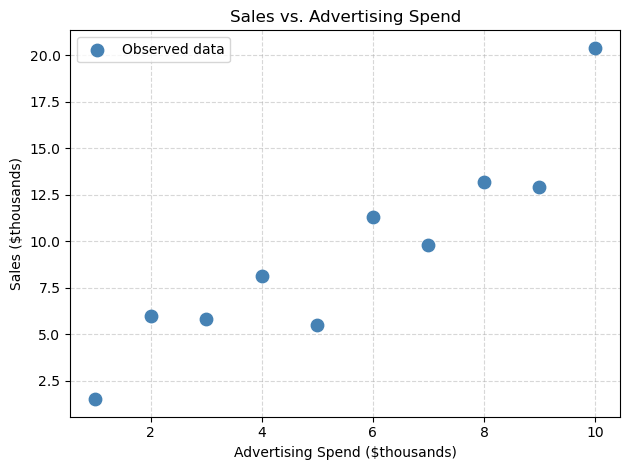

In [2]:
# Sales vs. Advertising dataset
advertising = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # $thousands spent
sales       = np.array([1.5, 6.0, 5.8, 8.1, 5.5, 11.3, 9.8, 13.2, 12.9, 20.4])  # $thousands earned

# Plot the scatter graph
plt.figure()
plt.scatter(advertising, sales, color='steelblue', s=80, zorder=5, label='Observed data')
plt.xlabel('Advertising Spend ($thousands)')
plt.ylabel('Sales ($thousands)')
plt.title('Sales vs. Advertising Spend')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Looking at the scatter plot above:

1. Does there appear to be a relationship between advertising spend and sales?
2. As advertising increases, what happens to sales?
3. If you spent **\$11,000** on advertising, what would you *predict* the sales to be? Write your estimate here:

**Your prediction:** _____


## 3. Determining the Line of Best Fit

When data shows a linear trend, we can draw a straight line through it. But which line is *best*?

Consider two candidate lines below. 

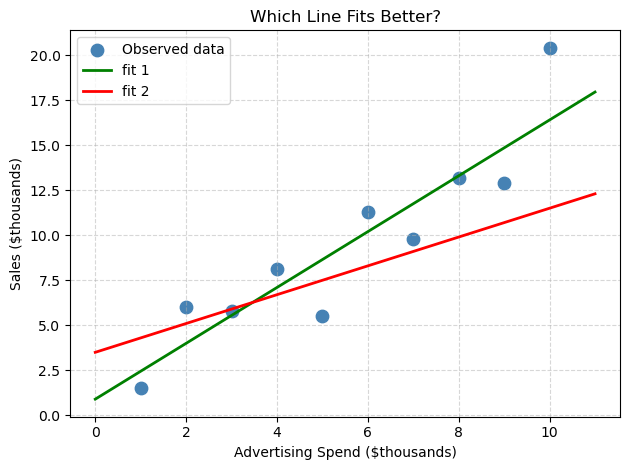

In [3]:
x_line = np.linspace(0, 11, 200)

# Two candidate lines
line_good = 1.55 * x_line + 0.9    # Close to the data
line_bad  = 0.8  * x_line + 3.5    # Poor fit

plt.figure()
plt.scatter(advertising, sales, color='steelblue', s=80, label='Observed data')
plt.plot(x_line, line_good, color='green',  linewidth=2, label='fit 1')
plt.plot(x_line, line_bad,  color='red',    linewidth=2, label='fit 2')
plt.xlabel('Advertising Spend ($thousands)')
plt.ylabel('Sales ($thousands)')
plt.title('Which Line Fits Better?')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The **line of best fit** (also called a regression line) is the line that minimizes the sum of the squared residuals, where a residual is the difference between an observed value and the value predicted by the line.

### What are Residuals?

A **residual** is the vertical distance between a data point and the fitted line:

$$\text{residual}_i = y_i - \hat{y}_i$$

where $y_i$ is the *observed* value and $\hat{y}_i$ is the *predicted* value from the line.

The **best fit line** minimizes the **Sum of Squared Residuals (SSR)**:

$$\text{SSR} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

This approach is called **Least Squares Regression**.

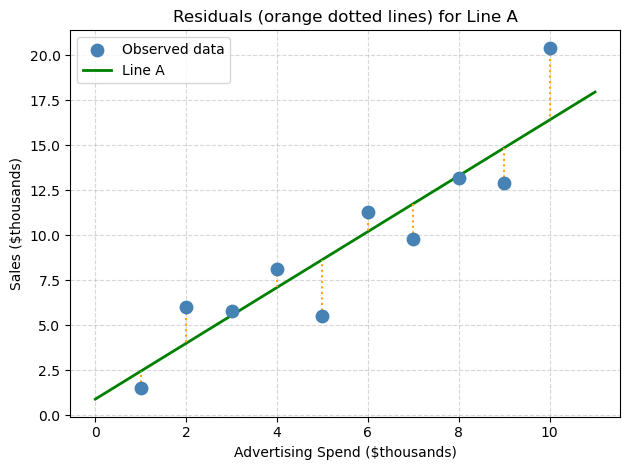

Sum of Squared Residuals (Line A): 40.7125


In [4]:
# Visualize the residuals for Line A (good fit)
predicted_good = 1.55 * advertising + 0.9

plt.figure()
plt.scatter(advertising, sales, color='steelblue', s=80, zorder=5, label='Observed data')
plt.plot(x_line, line_good, color='green', linewidth=2, label='Line A')

# Draw residual lines
for xi, yi, yi_hat in zip(advertising, sales, predicted_good):
    plt.plot([xi, xi], [yi, yi_hat], color='orange', linewidth=1.5, linestyle=':')

plt.xlabel('Advertising Spend ($thousands)')
plt.ylabel('Sales ($thousands)')
plt.title('Residuals (orange dotted lines) for Line A')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

ssr_good = np.sum((sales - predicted_good)**2)
print(f'Sum of Squared Residuals (Line A): {ssr_good:.4f}')

## 4. Using a Computer to Fit a Line

### What is `curve_fit`?

`curve_fit` from `scipy.optimize` automatically finds the **best-fit parameters** for any mathematical function you give it.

You need to provide:
1. A **Python function** that represents your mathematical model (e.g., `y = A*x + B`)
2. Your **x data** and **y data**

`curve_fit` returns:
- `popt` — the **optimal parameters** (e.g., the best values of A and B)
- `pcov` — the **parameter covariance matrix** (used to estimate uncertainty in the parameters)

If your model is:
$y = mx + b$
the `popt` contain the estimations for m and b<br><br>
`pcov` is a matrix like:

\[
\begin{bmatrix}
\mathrm{Var}(m) & \mathrm{Cov}(m,b) \\
\mathrm{Cov}(b,m) & \mathrm{Var}(b)
\end{bmatrix}
\]

syntax: `curve_fit(f, xdata, ydata, p0=None, sigma=None, absolute_sigma=False, check_finite=None, bounds=(-inf, inf), method=None, jac=None, *, full_output=False, nan_policy=None, **kwargs)`

### Example: Fitting a Linear Model

We want to fit:
$$y = Ax + B$$

Using the fitted model above, predict the sales if the advertising budget is **$11,000** (i.e., x = 11).

### Try It Yourself
find line of best fit for this:

>hint: $y = Ax^2 + B$

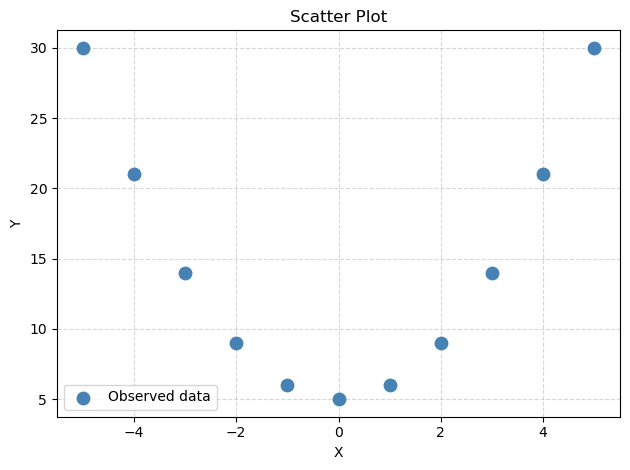

In [5]:
x = np.array([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])
y = np.array([30, 21, 14, 9, 6, 5, 6, 9, 14, 21, 30])

# Plot the scatter graph
plt.figure()
plt.scatter(x, y, color='steelblue', s=80, zorder=5, label='Observed data')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter Plot')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/t5/xr_vbyg52kn73c43qrnlzmnc0000gn/T/ipykernel_47089/1309686888.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(linear_model, x, y)


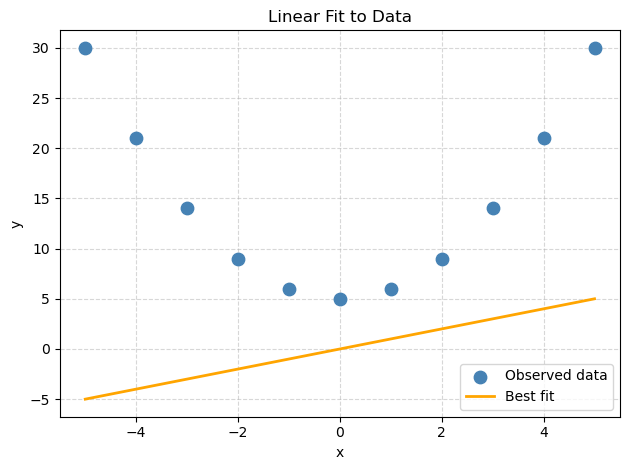

In [6]:
x = np.array([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])
y = np.array([30, 21, 14, 9, 6, 5, 6, 9, 14, 21, 30])

def linear_model(x, A, B):
    return x # TODO: modify this


popt, pcov = curve_fit(linear_model, x, y)
A_fit, B_fit = popt

y_fit = linear_model(x, A_fit, B_fit)

x_smooth = np.linspace(x.min(), x.max(), 300)
plt.figure()
plt.scatter(x, y, color='steelblue', s=80, zorder=5, label='Observed data')
plt.plot(x, y_fit, color='orange', linewidth=2, label='Best fit')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Fit to Data')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## How Good is the Fit? (Goodness of Fit)

After fitting a model, we need to ask: **how well does it describe the data?**

### The R² (R-squared) Score

R² is the most common measure of goodness of fit for linear fits. It tells you what **fraction of the variance** in your data is explained by the model.

$$R^2 = 1 - \frac{\text{SSR}}{\text{SST}}$$

Where:
- $\text{SSR} = \sum (y_i - \hat{y}_i)^2$ — Sum of Squared Residuals (error from model)
- $\text{SST} = \sum (y_i - \bar{y})^2$ — Total Sum of Squares (total variance in data)
- $\bar{y}$ — mean of the observed y values

| R² Value | Interpretation |
|----------|----------------|
| 1.0      | Perfect fit |
| 0.9–1.0  | Excellent fit |
| 0.7–0.9  | Good fit |
| < 0.7    | Poor fit |

## 5. Comparing Models: Atmospheric Density vs. Height

Now let's apply what we've learned to a real-world physics dataset.

The data below represents **atmospheric density** (kg/m³) at various **altitudes** (km) above Earth's surface.

We will test **three different models** and decide which one fits best:

| Model | Equation |
|-------|----------|
| Linear | $y = Ax + B$ |
| Quadratic | $y = Ax^2 + Bx + C$ |
| Exponential | $y = A\,e^{-Bx} + C$ |

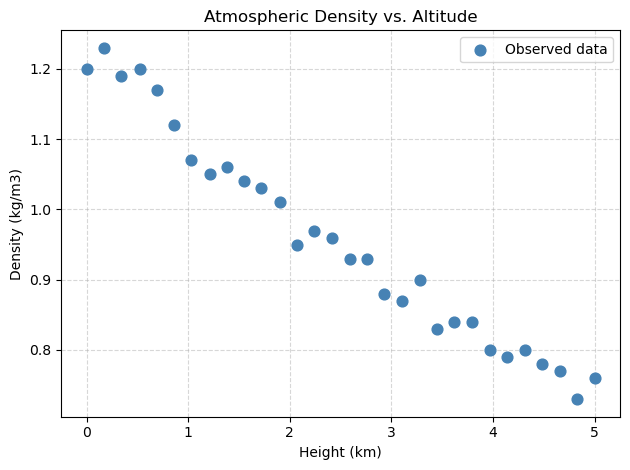

In [7]:
# Atmospheric density dataset
# Height in kilometers, density in kg/m3
height  = np.array([0.0,0.17,0.34,0.52,0.69,0.86,1.03,1.21,1.38,1.55,
                    1.72,1.9,2.07,2.24,2.41,2.59,2.76,2.93,3.1,3.28,
                    3.45,3.62,3.79,3.97,4.14,4.31,4.48,4.66,4.83,5.0])
density = np.array([1.2,1.23,1.19,1.2,1.17,1.12,1.07,1.05,1.06,1.04,
                    1.03,1.01,0.95,0.97,0.96,0.93,0.93,0.88,0.87,0.9,
                    0.83,0.84,0.84,0.8,0.79,0.8,0.78,0.77,0.73,0.76])

# Plot the raw data
plt.figure()
plt.scatter(height, density, color='steelblue', s=60, zorder=5, label='Observed data')
plt.xlabel('Height (km)')
plt.ylabel('Density (kg/m3)')
plt.title('Atmospheric Density vs. Altitude')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Step 1: Define All Three Model Functions

### Step 2: Fit All Three Models to the Data

### Step 3: Plot All Three Fits Together

### Step 4: Compare Goodness of Fit Using $R^2$

## 6. Summary: Using `curve_fit` — Step by Step

Here is a concise template you can reuse for any fitting problem:

Fitted parameters: [2.0000000e+00 4.4408921e-16]


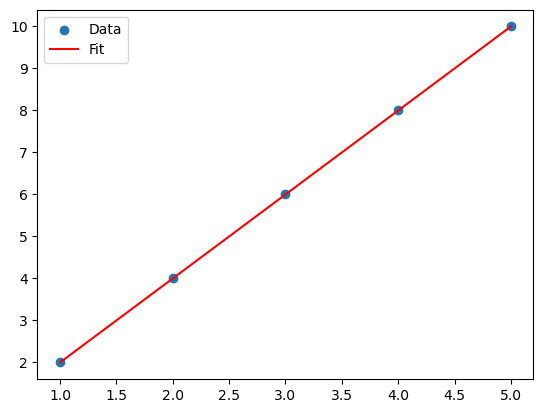

R2 = 1.0000


In [8]:
#  curve_fit template 
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# step 1. Your data 
x_data = np.array([1, 2, 3, 4, 5])
y_data = np.array([2, 4, 6, 8, 10])

# step 2. Define your model function
def my_model(x, A, B):
    return A * x + B 

# step 3. Fit the model 
popt, pcov = curve_fit(my_model, x_data, y_data)
print('Fitted parameters:', popt)

# step 4. Generate smooth fitted curve 
x_smooth = np.linspace(x_data.min(), x_data.max(), 300)
y_smooth = my_model(x_smooth, *popt)

# step 5. Plot 
plt.scatter(x_data, y_data, label='Data')
plt.plot(x_smooth, y_smooth, color='red', label='Fit')
plt.legend()
plt.show()

# step 6. Compute R2
y_pred = my_model(x_data, *popt)
ss_res = np.sum((y_data - y_pred)**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r2 = 1 - ss_res / ss_tot
print(f'R2 = {r2:.4f}')

## 7. Practice: Fit Your Own Model

Below is a new mystery dataset. Your task:

1. Plot the data
2. Decide which model (linear, quadratic, or exponential) looks best
3. Fit that model using `curve_fit`
4. Plot the data with the fitted curve
5. Calculate $R^2$ and report the result

**Hint:** Pay attention to the shape of the data. Does it curve? Is it symmetric?

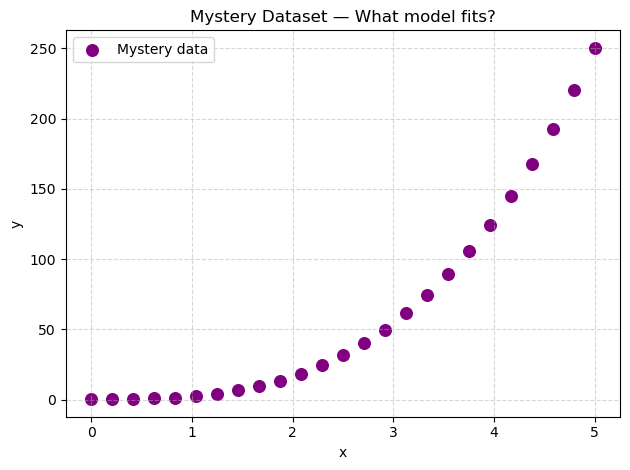

In [9]:
# Mystery dataset
np.random.seed(42)
x_mystery = np.linspace(0, 5, 25)
y_mystery = 2.0 * (x_mystery)**3 + 0.3 + np.random.normal(0, 0.05, 25)

# Step 1: Plot the raw data
plt.figure()
plt.scatter(x_mystery, y_mystery, color='purple', s=70, label='Mystery data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Mystery Dataset — What model fits?')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Step 2–5: Fit your chosen model and calculate R2
# YOUR CODE HERE
